## Indicators

In [ ]:
#!pip install geopandas contextily mapclassify  plotly tenacity==8.3.0 asyncio

In [1]:
from utils.settings import env 

In [24]:
from utils.indicators import Indicators

kpis = Indicators(verbose=False).request(
    address="Madrid, spain",
    boundary_type=13,
    resolution=15,
    #start_date='2021-01-01',
    sort_by='output_priceunit_official',
    ascending=0,
    geometry=True,
)

kpis.df

,boundary_id,boundary_type,boundary_admin,boundary_name,operation,construction_type,category_id,output_priceunit,output_priceunit_official,output_pricemean,...,output_priceunit_percentile50_raw,output_priceunit_percentile60_raw,output_priceunit_percentile70_raw,output_priceunit_percentile80_raw,output_priceunit_percentile90_raw,output_priceunit_percentile100_raw,md_liquidity,geometry,lat,lon
period_code,,,,,,,,,,,,,,,,,,,,,
2024Q1,26606,15,1-14-48-4440-13964-26606,Recoletos,1,2,0,11673.0,11667.0,2375000.0,...,11673.0,12400.0,13077.0,13780.0,14875.0,24483.0,8.0,"POLYGON ((-3.68189 40.42128, -3.68125 40.42140...",-3.685838,40.424600
2024Q1,26611,15,1-14-48-4440-13964-26611,Castellana,1,2,0,8861.0,8861.0,1450000.0,...,8861.0,9667.0,10274.0,11667.0,12692.0,22222.0,8.0,"POLYGON ((-3.67962 40.43146, -3.67954 40.43248...",-3.684295,40.433559
2024Q1,26627,15,1-14-48-4440-13967-26627,Almagro,1,2,0,8173.0,8170.0,1680000.0,...,8173.0,8884.0,9519.0,10360.0,11286.0,16111.0,9.0,"POLYGON ((-3.68936 40.42938, -3.68904 40.43058...",-3.693538,40.432855
2024Q1,26604,15,1-14-48-4440-13963-26604,Jerónimos,1,2,0,8544.0,7942.0,1195000.0,...,8544.0,9615.0,10000.0,13212.0,14983.0,23636.0,6.0,"POLYGON ((-3.68850 40.40703, -3.68844 40.40700...",-3.685113,40.413769
2024Q1,26610,15,1-14-48-4440-13964-26610,Lista,1,2,0,7244.0,7433.0,790000.0,...,7244.0,7778.0,8571.0,9000.0,9993.0,15000.0,9.0,"POLYGON ((-3.66908 40.42844, -3.67021 40.42980...",-3.675789,40.432018
2024Q1,26590,15,1-14-48-4440-13961-26590,Justicia,1,2,0,7333.0,7336.0,800000.0,...,7333.0,7960.0,8531.0,9565.0,11742.0,14706.0,8.0,"POLYGON ((-3.69534 40.41898, -3.69498 40.41904...",-3.696673,40.423650
2024Q1,26607,15,1-14-48-4440-13964-26607,Goya,1,2,0,7263.0,7263.0,780000.0,...,7263.0,7895.0,8361.0,9096.0,10465.0,14231.0,9.0,"POLYGON ((-3.66877 40.42371, -3.66876 40.42382...",-3.674430,40.425052
2024Q1,26612,15,1-14-48-4440-13965-26612,El Viso,1,2,0,7222.0,7222.0,1145000.0,...,7222.0,7619.0,8000.0,8889.0,10000.0,12222.0,9.0,"POLYGON ((-3.67862 40.44233, -3.67841 40.44424...",-3.684781,40.444870
2024Q1,26603,15,1-14-48-4440-13963-26603,Ibiza,1,2,0,7064.0,7064.0,750000.0,...,7064.0,7500.0,7786.0,8385.0,8839.0,15000.0,9.0,"POLYGON ((-3.66927 40.41805, -3.66920 40.41879...",-3.674337,40.418884


In [25]:
import folium
import branca

feat = "output_priceunit"

# Create the colomap styles
colormap = branca.colormap.LinearColormap(
    vmin=kpis.df[feat].quantile(0.0),
    vmax=kpis.df[feat].quantile(1),
    colors=["red", "orange", "lightblue", "green", "darkgreen"],
    caption=feat,
)

style=dict(weight=.05)

kpis.df.explore(
    tooltip=['boundary_name', feat],
    column=feat, 
    #cmap='Blues',
    style_kwds=style,
    tiles='CartoDB positron',
)

In [26]:
import plotly.express as px
import matplotlib.pyplot as plt

kpis = Indicators().request(
    address="Barcelona, spain",
    boundary_type=13,
    resolution=15,
    sort_by='output_priceunit',
    ascending=0,
    #geometry=True,
    limit=5
)

df = kpis.df

selection = df.boundary_id.unique().tolist()

selection

[20455, 20441, 20458, 20501, 20457]

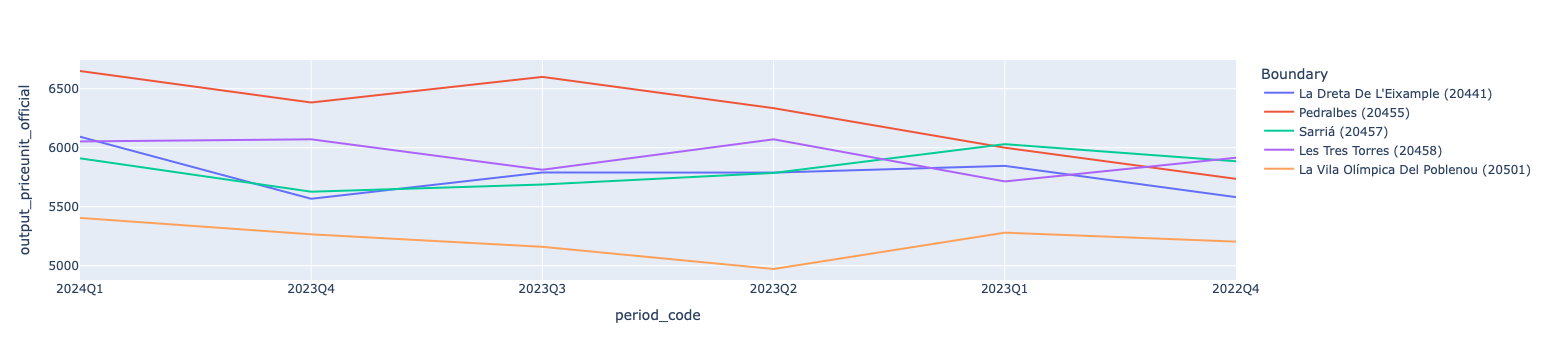

,boundary_id,boundary_type,boundary_admin,boundary_name,operation,construction_type,category_id,output_priceunit,output_priceunit_official,output_pricemean,...,output_priceunit_percentile30_raw,output_priceunit_percentile40_raw,output_priceunit_percentile50_raw,output_priceunit_percentile60_raw,output_priceunit_percentile70_raw,output_priceunit_percentile80_raw,output_priceunit_percentile90_raw,output_priceunit_percentile100_raw,md_liquidity,Boundary
period_code,,,,,,,,,,,,,,,,,,,,,
2024Q1,20441,15,1-10-28-953-9454-20441,La Dreta De L'Eixample,1,2,0,6093.0,6093.0,795500.0,...,5250.0,5506.0,6093.0,6727.0,7412.0,8333.0,9690.0,16176.0,6.0,La Dreta De L'Eixample (20441)
2024Q1,20455,15,1-10-28-953-9456-20455,Pedralbes,1,2,0,6649.0,6650.0,1290000.0,...,5841.0,6197.0,6649.0,7133.0,7348.0,8333.0,8582.0,17693.0,0.0,Pedralbes (20455)
2024Q1,20457,15,1-10-28-953-9457-20457,Sarriá,1,2,0,5769.0,5910.0,760000.0,...,5378.0,5769.0,5769.0,6080.0,6474.0,6750.0,8136.0,10536.0,8.0,Sarriá (20457)
2024Q1,20458,15,1-10-28-953-9457-20458,Les Tres Torres,1,2,0,6053.0,6053.0,1200000.0,...,5442.0,5594.0,6053.0,6333.0,6834.0,7500.0,7919.0,9612.0,9.0,Les Tres Torres (20458)
2024Q1,20501,15,1-10-28-953-9462-20501,La Vila Olímpica Del Poblenou,1,2,0,5779.0,5405.0,480000.0,...,4586.0,5083.0,5779.0,5913.0,6274.0,6531.0,7071.0,7313.0,9.0,La Vila Olímpica Del Poblenou (20501)
2023Q4,20441,15,1-10-28-953-9454-20441,La Dreta De L'Eixample,1,2,0,5565.0,5567.0,690000.0,...,4538.0,5077.0,5565.0,6143.0,6729.0,7486.0,9000.0,19714.0,6.0,La Dreta De L'Eixample (20441)
2023Q4,20455,15,1-10-28-953-9456-20455,Pedralbes,1,2,0,6383.0,6383.0,1150000.0,...,5805.0,6053.0,6383.0,6557.0,6990.0,7178.0,8175.0,10623.0,2.0,Pedralbes (20455)
2023Q4,20457,15,1-10-28-953-9457-20457,Sarriá,1,2,0,5992.0,5627.0,779000.0,...,5534.0,5730.0,5992.0,6228.0,6618.0,7029.0,7544.0,11739.0,6.0,Sarriá (20457)
2023Q4,20458,15,1-10-28-953-9457-20458,Les Tres Torres,1,2,0,6071.0,6071.0,1190000.0,...,5528.0,5938.0,6071.0,6325.0,6739.0,7200.0,7629.0,9184.0,6.0,Les Tres Torres (20458)


In [29]:
kpis = Indicators().request(
    boundary_id=",".join([str(b) for b in selection]),
    start_date='2007-01-01',
    sort_by='period_code',
    ascending=0
    
)

kpis.df['Boundary'] = kpis.df.apply(lambda x: f"{x['boundary_name']} ({x['boundary_id']})", axis=1)

fig = px.line(kpis.df.reset_index(), x="period_code", y="output_priceunit_official", color="Boundary")
fig.show()

kpis.df